<a href="https://colab.research.google.com/github/ahmad0719/ML_Project/blob/main/atomcamp_ml_notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 atomcamp AI Bootcamp — Machine Learning Module
## Hands-On Notebook: Scikit-learn · TensorFlow · PyTorch

---

**Lecture:** Overview of ML + Supervised Learning & Linear Regression  
**Duration:** ~15 minutes hands-on (follow the 🔨 markers)  
**Goal:** Run the same pipeline — load → clean → predict — across 3 different libraries

| Section | Library | Dataset | Task |
|---------|---------|---------|------|
| 1 | Scikit-learn | California Housing (StatLib/UCI) | Predict median house value |
| 2 | TensorFlow/Keras | Wine Quality (UCI ML Repo) | Predict wine quality score |
| 3 | PyTorch | Diabetes (NIDDK/Efron et al.) | Predict disease progression |

---
**Instructions:** Run each cell from top to bottom using `Shift + Enter`. Don't skip cells!  
Look for `# 🔨 YOUR TURN` comments — those are exercises for you to complete.


In [ ]:
# ============================================================
# CELL 0 — Install / Import shared dependencies
# Run this first! It sets up everything we need.
# ============================================================
!pip install -q scikit-learn tensorflow torch pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')
print('✅ All libraries ready!')

✅ All libraries ready!


---
# 🟢 SECTION 1 — Scikit-learn
## Dataset: California Housing (StatLib Repository, originally published 1990)

> **Citation:** Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. *Statistics & Probability Letters*, 33(3), 291-297.  
> **Source:** https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset  
> **Size:** 20,640 samples | 8 features | Target: median house value (in $100,000s)

**Features:**
- `MedInc` — Median income in block group
- `HouseAge` — Median house age
- `AveRooms` — Average number of rooms
- `AveBedrms` — Average number of bedrooms
- `Population` — Block group population
- `AveOccup` — Average household size
- `Latitude` — Block group latitude
- `Longitude` — Block group longitude

In [ ]:
# ============================================================
# CELL 1.1 — LOAD THE DATASET
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load as a pandas DataFrame (as_frame=True is key!)
data = fetch_california_housing(as_frame=True)
df = data.frame

print('🏠 California Housing Dataset Loaded!')
print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')
print()
print('📋 First 5 rows:')
df.head()

🏠 California Housing Dataset Loaded!
Shape: (20640, 9)  (20,640 rows × 9 columns)

📋 First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# ============================================================
# CELL 1.2 — EXPLORE THE DATA
# ============================================================
print('📊 Basic Statistics:')
print(df.describe().round(2))
print()
print('📏 Column data types:')
print(df.dtypes)

📊 Basic Statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.

🔍 Missing Values Check:
             Missing Count  Missing %
MedInc                   0        0.0
HouseAge                 0        0.0
AveRooms                 0        0.0
AveBedrms                0        0.0
Population               0        0.0
AveOccup                 0        0.0
Latitude                 0        0.0
Longitude                0        0.0
MedHouseVal              0        0.0

Total missing values: 0
✅ Great! No missing values in this dataset.


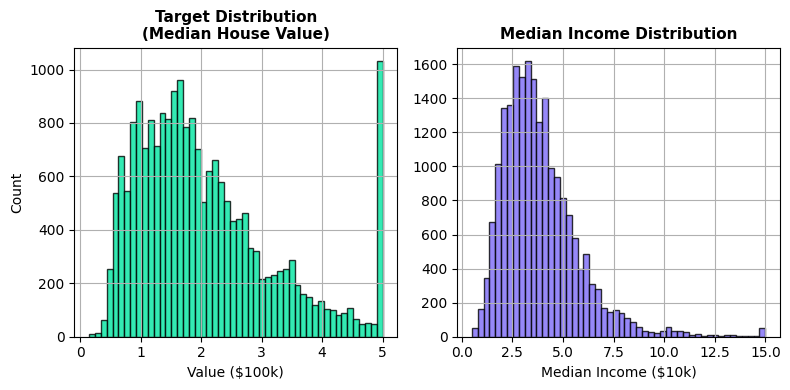

Notice the spike at 5.0 in house values — that's the dataset cap at $500,000!


In [ ]:
# ============================================================
# CELL 1.3 — CHECK FOR MISSING VALUES
# This is ALWAYS the first thing you do with a new dataset!
# ============================================================
print('🔍 Missing Values Check:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)
print()
print(f'Total missing values: {df.isnull().sum().sum()}')
print('✅ Great! No missing values in this dataset.')

# Visualise the distribution of the target variable
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
df['MedHouseVal'].hist(bins=50, color='#00e5a0', edgecolor='black', alpha=0.8)
plt.title('Target Distribution\n(Median House Value)', fontsize=11, fontweight='bold')
plt.xlabel('Value ($100k)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['MedInc'].hist(bins=50, color='#7c6af7', edgecolor='black', alpha=0.8)
plt.title('Median Income Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Median Income ($10k)')

plt.tight_layout()
plt.show()
print('Notice the spike at 5.0 in house values — that\'s the dataset cap at $500,000!')

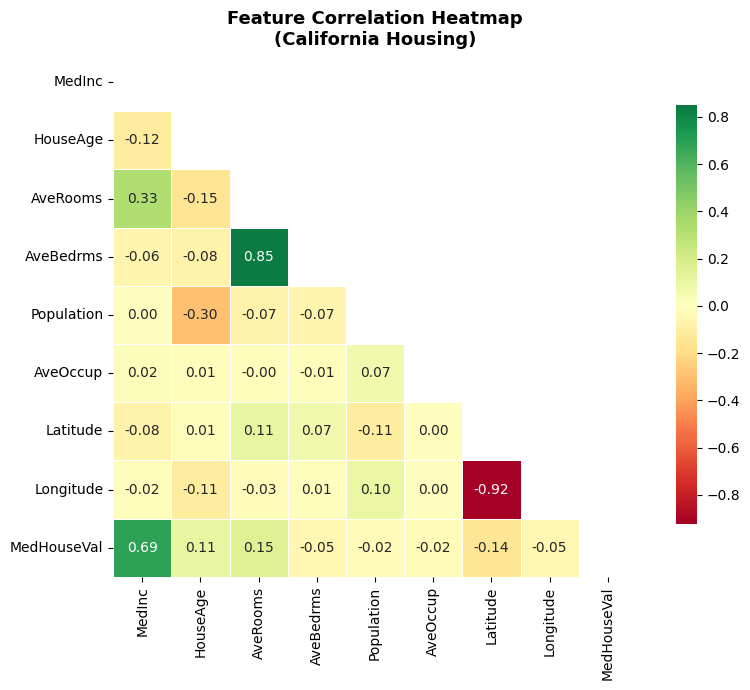


🎯 Correlation with MedHouseVal (Target):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160

💡 MedInc has the strongest positive correlation — richer areas = higher house prices. Makes sense!


In [ ]:
# ============================================================
# CELL 1.4 — CORRELATION HEATMAP
# Which features correlate most with the house price?
# ============================================================
plt.figure(figsize=(9, 7))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap\n(California Housing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Report top correlations with target
print('\n🎯 Correlation with MedHouseVal (Target):')
print(corr_matrix['MedHouseVal'].sort_values(ascending=False).to_string())
print('\n💡 MedInc has the strongest positive correlation — richer areas = higher house prices. Makes sense!')

In [ ]:
# ============================================================
# CELL 1.5 — PREPARE DATA FOR MODELLING
# Features (X) and Target (y), then train/test split
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('MedHouseVal', axis=1)   # all columns except the target
y = df['MedHouseVal']                 # this is what we're predicting

print(f'Features (X): {X.shape}')
print(f'Target   (y): {y.shape}')
print(f'Feature names: {list(X.columns)}')

# Train/Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'\nTraining set: {X_train.shape[0]:,} samples')
print(f'Testing set:  {X_test.shape[0]:,} samples')

# Scale features — CRITICAL for linear models!
# fit_transform on train, ONLY transform on test (never fit on test!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Data is ready for training!')
print(f'Before scaling — MedInc range: [{X_train["MedInc"].min():.1f}, {X_train["MedInc"].max():.1f}]')
print(f'After scaling  — MedInc range: [{X_train_scaled[:,0].min():.1f}, {X_train_scaled[:,0].max():.1f}]')

Features (X): (20640, 8)
Target   (y): (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Training set: 16,512 samples
Testing set:  4,128 samples

✅ Data is ready for training!
Before scaling — MedInc range: [0.5, 15.0]
After scaling  — MedInc range: [-1.8, 5.8]


In [ ]:
# ============================================================
# CELL 1.6 — TRAIN LINEAR REGRESSION MODEL
# The fit() call is where ALL the learning happens!
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Instantiate
lr_model = LinearRegression()

# 2. Train (fit)
lr_model.fit(X_train_scaled, y_train)
print('✅ Model trained!')

# 3. Predict
y_pred = lr_model.predict(X_test_scaled)

# 4. Evaluate
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print()
print('📊 MODEL PERFORMANCE (Test Set):')
print(f'  RMSE : {rmse:.4f}  (in $100k units — off by ~${rmse*100_000:,.0f} on average)')
print(f'  MAE  : {mae:.4f}')
print(f'  R²   : {r2:.4f}  (model explains {r2*100:.1f}% of variance)')

print()
print('Feature Coefficients (how much each feature moves the price):')
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

✅ Model trained!

📊 MODEL PERFORMANCE (Test Set):
  RMSE : 0.7456  (in $100k units — off by ~$74,558 on average)
  MAE  : 0.5332
  R²   : 0.5758  (model explains 57.6% of variance)

Feature Coefficients (how much each feature moves the price):
   Feature  Coefficient
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929


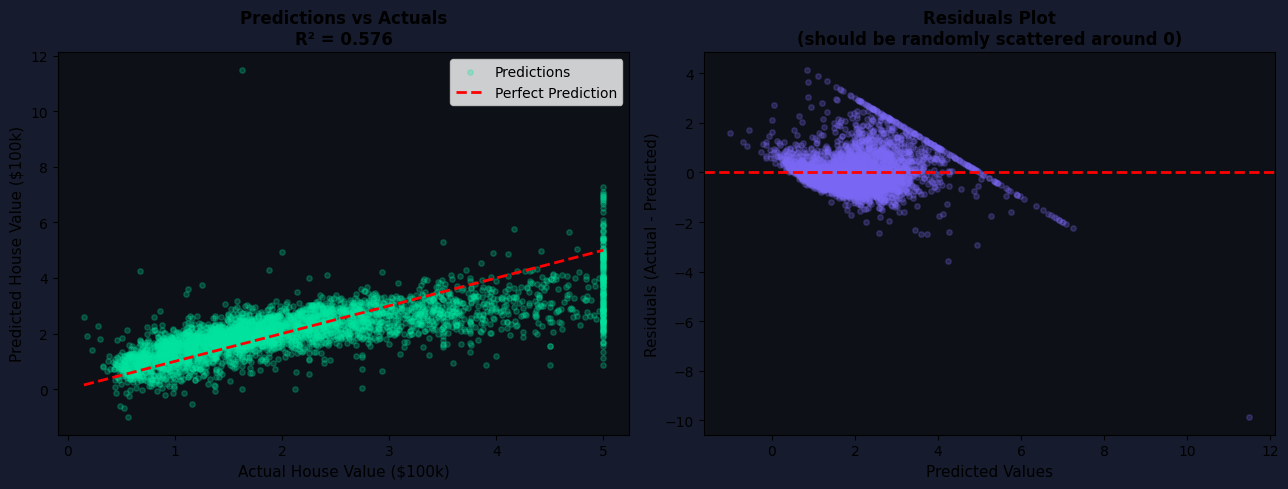

🔍 OBSERVATIONS:
  - Points scatter around the red diagonal — model is learning!
  - Slight "fan" shape at higher values → price cap in data affects accuracy
  - The flat cluster at 5.0 is from the $500k cap in the original dataset


In [ ]:
# ============================================================
# CELL 1.7 — VISUALISE: PREDICTIONS VS ACTUALS
# A well-trained model should cluster around the diagonal line
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Predictions vs Actuals ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.25, color='#00e5a0', s=15, label='Predictions')
perfect_line = [y_test.min(), y_test.max()]
ax1.plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual House Value ($100k)', fontsize=11)
ax1.set_ylabel('Predicted House Value ($100k)', fontsize=11)
ax1.set_title(f'Predictions vs Actuals\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.set_facecolor('#0d1117')
ax1.figure.patch.set_facecolor('#161c2d')

# --- Plot 2: Residuals ---
residuals = y_test.values - y_pred
ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.25, color='#7c6af7', s=15)
ax2.axhline(y=0, color='red', linewidth=2, linestyle='--')
ax2.set_xlabel('Predicted Values', fontsize=11)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax2.set_title('Residuals Plot\n(should be randomly scattered around 0)', fontsize=12, fontweight='bold')
ax2.set_facecolor('#0d1117')

plt.tight_layout()
plt.show()

print('🔍 OBSERVATIONS:')
print('  - Points scatter around the red diagonal — model is learning!')
print('  - Slight "fan" shape at higher values → price cap in data affects accuracy')
print('  - The flat cluster at 5.0 is from the $500k cap in the original dataset')

In [ ]:
# ============================================================
# 🔨 YOUR TURN — Exercise 1
# ============================================================
# The model currently uses ALL 8 features.
# Try using ONLY the top 3 correlated features: MedInc, AveRooms, HouseAge
# Does the R² go up or down? Why do you think that is?

# YOUR CODE HERE:
# X_small = df[['MedInc', 'AveRooms', 'HouseAge']]
# ... (follow the same steps as above)

print('💪 Challenge: Can you beat R² = 0.60 using only these 3 features?')

💪 Challenge: Can you beat R² = 0.60 using only these 3 features?


---
# 🟠 SECTION 2 — TensorFlow / Keras
## Dataset: Wine Quality Red (UCI Machine Learning Repository)

> **Citation:** Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.  
> **Source:** https://archive.ics.uci.edu/dataset/186/wine+quality  
> **Size:** 1,599 red wine samples | 11 features | Target: quality score (3–8)

**Features:** fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol  
**Target:** quality (integer 3–8, human taste-test rating)

In [ ]:
# ============================================================
# CELL 2.1 — LOAD WINE QUALITY DATASET FROM UCI
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

print(f'TensorFlow version: {tf.__version__}')

# Load directly from UCI ML Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df_wine = pd.read_csv(url, sep=';')

print(f'\n🍷 Wine Quality Dataset Loaded!')
print(f'Shape: {df_wine.shape}  ({df_wine.shape[0]:,} rows × {df_wine.shape[1]} columns)')
print()
print('📋 First 5 rows:')
df_wine.head()

TensorFlow version: 2.19.0

🍷 Wine Quality Dataset Loaded!
Shape: (1599, 12)  (1,599 rows × 12 columns)

📋 First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


🔍 Missing Values Check:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0
Duplicate rows found: 240
Shape after removing duplicates: (1359, 12)


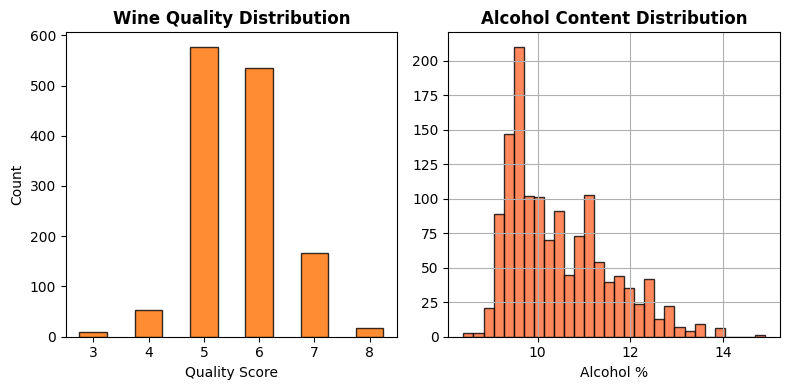


💡 Most wines score 5 or 6. Very few score 3 (terrible) or 8 (excellent).
This imbalance is something to keep in mind when evaluating the model!


In [ ]:
# ============================================================
# CELL 2.2 — MISSING VALUES & DATA QUALITY CHECK
# ============================================================
print('🔍 Missing Values Check:')
print(df_wine.isnull().sum())
print(f'\nTotal missing: {df_wine.isnull().sum().sum()}')

# Check for duplicates (a common real-world problem!)
duplicates = df_wine.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

# Remove duplicates
df_wine = df_wine.drop_duplicates()
print(f'Shape after removing duplicates: {df_wine.shape}')

# Distribution of the target (quality scores)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
df_wine['quality'].value_counts().sort_index().plot(
    kind='bar', color='#FF6F00', edgecolor='black', alpha=0.8
)
plt.title('Wine Quality Distribution', fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df_wine['alcohol'].hist(bins=30, color='#ff6b35', edgecolor='black', alpha=0.8)
plt.title('Alcohol Content Distribution', fontweight='bold')
plt.xlabel('Alcohol %')

plt.tight_layout()
plt.show()

print('\n💡 Most wines score 5 or 6. Very few score 3 (terrible) or 8 (excellent).')
print('This imbalance is something to keep in mind when evaluating the model!')

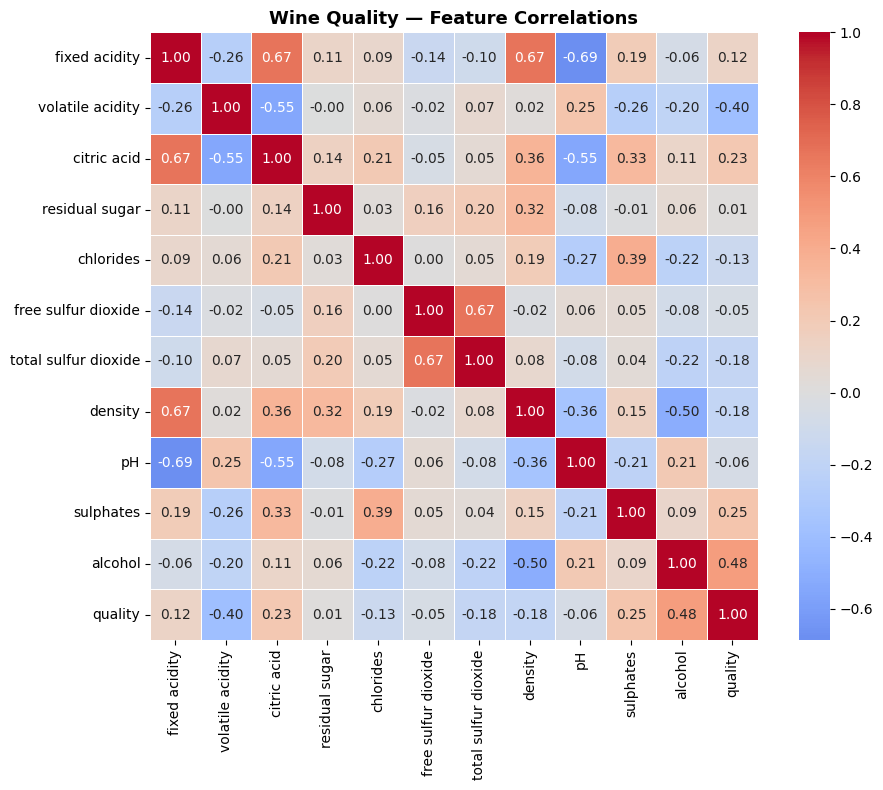

Top features correlated with quality:
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [ ]:
# ============================================================
# CELL 2.3 — FEATURE CORRELATION ANALYSIS
# ============================================================
plt.figure(figsize=(10, 8))
corr = df_wine.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Wine Quality — Feature Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features correlated with quality:')
print(corr['quality'].sort_values(ascending=False).drop('quality'))

In [ ]:
# ============================================================
# CELL 2.4 — PREPARE DATA
# ============================================================
X_wine = df_wine.drop('quality', axis=1).values
y_wine = df_wine['quality'].values.astype(np.float32)

X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_wine, y_wine, test_size=0.20, random_state=42
)

sc_wine = StandardScaler()
X_tr_w = sc_wine.fit_transform(X_tr_w).astype(np.float32)
X_te_w = sc_wine.transform(X_te_w).astype(np.float32)

print(f'Training: {X_tr_w.shape} | Testing: {X_te_w.shape}')
print(f'Input features per sample: {X_tr_w.shape[1]}')
print('✅ Data ready for TensorFlow!')

Training: (1087, 11) | Testing: (272, 11)
Input features per sample: 11
✅ Data ready for TensorFlow!


In [ ]:
# ============================================================
# CELL 2.5 — BUILD NEURAL NETWORK WITH KERAS
# We use a 3-layer dense network (fully connected)
# ============================================================
from tensorflow import keras

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

def build_wine_model(n_features):
    """Build a simple dense neural network for regression."""
    model = keras.Sequential([
        # Layer 1: Input layer with 64 neurons, ReLU activation
        keras.layers.Dense(64, activation='relu', input_shape=(n_features,)),
        keras.layers.BatchNormalization(),   # helps training stability
        keras.layers.Dropout(0.1),           # prevents overfitting

        # Layer 2: Hidden layer with 32 neurons
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.1),

        # Layer 3: Hidden layer with 16 neurons
        keras.layers.Dense(16, activation='relu'),

        # Output: Single neuron (regression — predicts a number)
        keras.layers.Dense(1)
    ], name='WineQualityPredictor')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',         # Mean Squared Error loss
        metrics=['mae']     # Mean Absolute Error as readable metric
    )
    return model

wine_model = build_wine_model(X_tr_w.shape[1])
wine_model.summary()

Model: "WineQualityPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# ============================================================
# CELL 2.6 — TRAIN THE MODEL
# Watch the loss go down each epoch — that's learning happening!
# ============================================================
# Early stopping: stop if validation loss doesn't improve for 15 epochs
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

history = wine_model.fit(
    X_tr_w, y_tr_w,
    epochs=150,
    batch_size=32,
    validation_split=0.1,   # 10% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

print('\n✅ Training complete!')

Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 21.1235 - mae: 4.3832 - val_loss: 21.9707 - val_mae: 4.6005
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.1985 - mae: 2.1089 - val_loss: 12.7744 - val_mae: 3.4488
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.9627 - mae: 1.3910 - val_loss: 11.3346 - val_mae: 3.2585
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.1681 - mae: 1.1716 - val_loss: 9.2972 - val_mae: 2.9417
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.6146 - mae: 0.9977 - val_loss: 7.3632 - val_mae: 2.5992
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.6336 - mae: 1.0061 - val_loss: 5.6963 - val_mae: 2.2555
Epoch 7/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.3808 - mae: 0.9329 - val_loss: 4.6711 - val_mae: 2.0274
Epoch 8/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5021 - mae: 0.9684 - val_loss: 3.5055 - val_mae: 1.7102
Epoch 9/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - 

🍷 WINE MODEL PERFORMANCE (Test Set):
  MAE  : 0.5543  (off by ~0.55 quality points on average)
  RMSE : 0.7222
  R²   : 0.2637


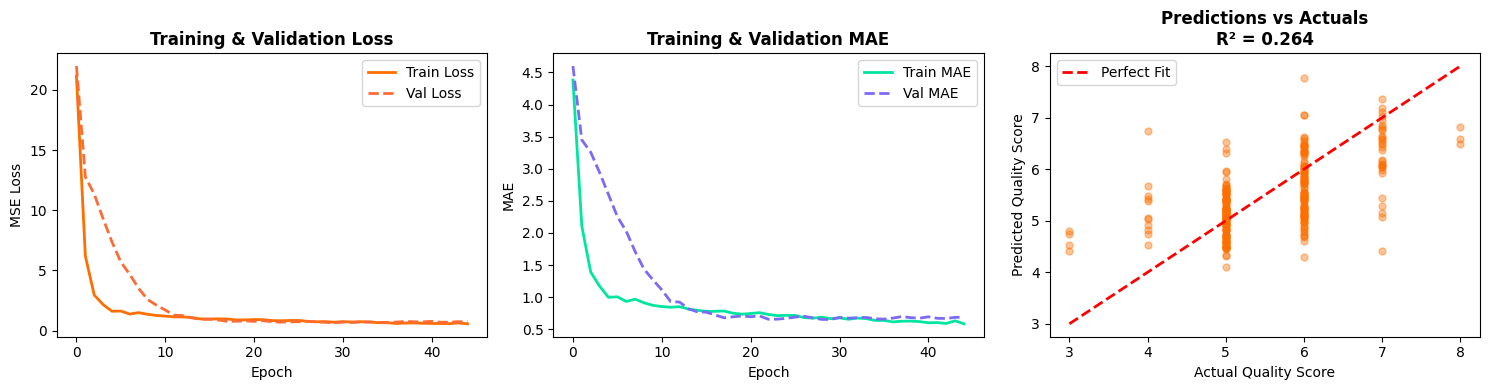


💡 The training curve going DOWN means the model is learning!
When train and val curves diverge (train↓ but val↑), that's OVERFITTING.


In [ ]:
# ============================================================
# CELL 2.7 — EVALUATE & VISUALISE
# ============================================================
# Evaluate on test set
test_loss, test_mae = wine_model.evaluate(X_te_w, y_te_w, verbose=0)
y_pred_wine = wine_model.predict(X_te_w, verbose=0).flatten()
r2_wine = r2_score(y_te_w, y_pred_wine)

print('🍷 WINE MODEL PERFORMANCE (Test Set):')
print(f'  MAE  : {test_mae:.4f}  (off by ~{test_mae:.2f} quality points on average)')
print(f'  RMSE : {np.sqrt(test_loss):.4f}')
print(f'  R²   : {r2_wine:.4f}')

# ── Plot training history ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training loss curve
ax1 = axes[0]
ax1.plot(history.history['loss'],     label='Train Loss', color='#FF6F00', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss',   color='#ff6b35', lw=2, linestyle='--')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()

# MAE curve
ax2 = axes[1]
ax2.plot(history.history['mae'],     label='Train MAE', color='#00e5a0', lw=2)
ax2.plot(history.history['val_mae'], label='Val MAE',   color='#7c6af7', lw=2, linestyle='--')
ax2.set_title('Training & Validation MAE', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()

# Predictions vs Actuals
ax3 = axes[2]
ax3.scatter(y_te_w, y_pred_wine, alpha=0.4, color='#FF6F00', s=25)
ax3.plot([3, 8], [3, 8], 'r--', lw=2, label='Perfect Fit')
ax3.set_xlabel('Actual Quality Score')
ax3.set_ylabel('Predicted Quality Score')
ax3.set_title(f'Predictions vs Actuals\nR² = {r2_wine:.3f}', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

print('\n💡 The training curve going DOWN means the model is learning!')
print('When train and val curves diverge (train↓ but val↑), that\'s OVERFITTING.')

In [ ]:
# ============================================================
# 🔨 YOUR TURN — Exercise 2
# ============================================================
# The model currently has 3 hidden layers (64 → 32 → 16).
# Try changing it to 2 layers only (64 → 32).
# Does the model perform better or worse? Why might that be?

# YOUR CODE HERE:
# wine_model_v2 = keras.Sequential([...your layers...])

print('💪 Experiment: Can fewer layers sometimes work better? Test it!')

💪 Experiment: Can fewer layers sometimes work better? Test it!


---
# 🟣 SECTION 3 — PyTorch
## Dataset: Diabetes (NIDDK / Efron et al., Annals of Statistics 2004)

> **Citation:** Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least Angle Regression. *The Annals of Statistics*, 32(2), 407-499.  
> **Source:** https://scikit-learn.org/stable/datasets/toy.html#diabetes-dataset  
> **Size:** 442 patients | 10 features | Target: disease progression score after 1 year

**Features:** age, sex, BMI, blood pressure, 6 blood serum measurements  
**Target:** Quantitative measure of diabetes disease progression (higher = worse)

In [ ]:
# ============================================================
# CELL 3.1 — LOAD DIABETES DATASET
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load dataset
diabetes_data = load_diabetes()
X_diab = diabetes_data.data
y_diab = diabetes_data.target
feature_names = diabetes_data.feature_names

# Convert to DataFrame for exploration
df_diab = pd.DataFrame(X_diab, columns=feature_names)
df_diab['target'] = y_diab

print(f'\n💉 Diabetes Dataset Loaded!')
print(f'Shape: {df_diab.shape}  ({df_diab.shape[0]} rows × {df_diab.shape[1]} columns)')
print(f'Feature names: {feature_names}')
print()
df_diab.head()

PyTorch version: 2.10.0+cpu
Using device: cpu

💉 Diabetes Dataset Loaded!
Shape: (442, 11)  (442 rows × 11 columns)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


🔍 Missing Values Check (numpy):
  Total NaN values: 0
  Shape: (442, 10)

📊 Target Statistics (disease progression):
  Min:  25.0
  Max:  346.0
  Mean: 152.1
  Std:  77.0


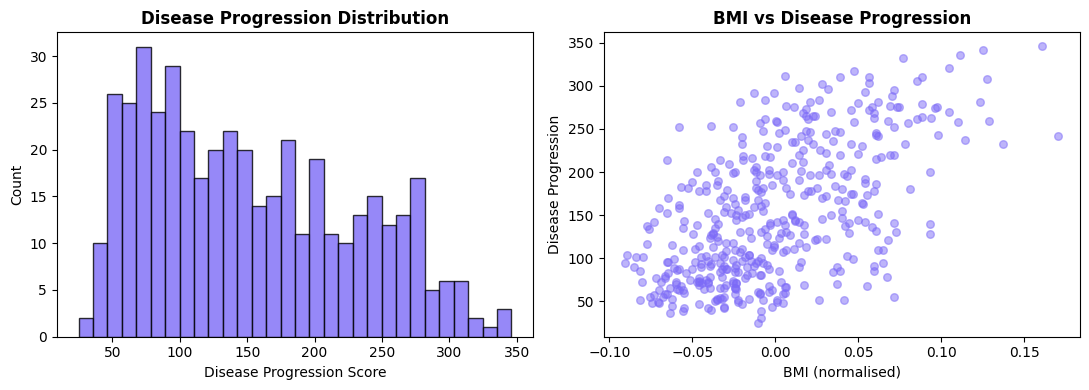


💡 Note: Features in this dataset are already mean-centred and scaled by sklearn.
We still apply our own StandardScaler to demonstrate the pipeline correctly.


In [ ]:
# ============================================================
# CELL 3.2 — MISSING VALUES & EXPLORATION
# ============================================================
print('🔍 Missing Values Check (numpy):')
nan_count = np.isnan(X_diab).sum()
print(f'  Total NaN values: {nan_count}')
print(f'  Shape: {X_diab.shape}')

# Note: sklearn datasets are pre-normalised for features
# but target is NOT scaled
print(f'\n📊 Target Statistics (disease progression):')
print(f'  Min:  {y_diab.min():.1f}')
print(f'  Max:  {y_diab.max():.1f}')
print(f'  Mean: {y_diab.mean():.1f}')
print(f'  Std:  {y_diab.std():.1f}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_diab, bins=30, color='#7c6af7', edgecolor='black', alpha=0.8)
axes[0].set_title('Disease Progression Distribution', fontweight='bold')
axes[0].set_xlabel('Disease Progression Score')
axes[0].set_ylabel('Count')

# BMI vs target (most clinically intuitive feature)
axes[1].scatter(df_diab['bmi'], y_diab, alpha=0.5, color='#7c6af7', s=30)
axes[1].set_title('BMI vs Disease Progression', fontweight='bold')
axes[1].set_xlabel('BMI (normalised)')
axes[1].set_ylabel('Disease Progression')

plt.tight_layout()
plt.show()

print('\n💡 Note: Features in this dataset are already mean-centred and scaled by sklearn.')
print('We still apply our own StandardScaler to demonstrate the pipeline correctly.')

In [ ]:
# ============================================================
# CELL 3.3 — PREPARE DATA AND CONVERT TO PYTORCH TENSORS
# This is unique to PyTorch — data must become Tensors!
# ============================================================
torch.manual_seed(42)
np.random.seed(42)

# Train/Test split
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_diab, y_diab, test_size=0.20, random_state=42
)

# Scale features
sc_diab = StandardScaler()
X_tr_d = sc_diab.fit_transform(X_tr_d)
X_te_d = sc_diab.transform(X_te_d)

print(f'Training: {X_tr_d.shape} | Testing: {X_te_d.shape}')

# ── Convert numpy arrays to PyTorch Tensors ──
# A Tensor is PyTorch's core data structure (like numpy array but GPU-ready)
X_train_t = torch.FloatTensor(X_tr_d).to(device)
X_test_t  = torch.FloatTensor(X_te_d).to(device)
y_train_t = torch.FloatTensor(y_tr_d).unsqueeze(1).to(device)  # shape: (N, 1)
y_test_t  = torch.FloatTensor(y_te_d).unsqueeze(1).to(device)

print(f'\nTensor shapes:')
print(f'  X_train_t: {X_train_t.shape}  (353 samples, 10 features)')
print(f'  y_train_t: {y_train_t.shape}  (353 samples, 1 target value each)')
print(f'\nData type: {X_train_t.dtype}')

# Use DataLoader for batching (good habit even for small datasets)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,
                           drop_last=True)  # ← drop final batch if it has 1 sample (fixes BatchNorm1d crash)
print(f'DataLoader batches per epoch: {len(train_loader)}')
print(f'Training samples used: {len(train_loader) * 32} of {len(train_dataset)}')

Training: (353, 10) | Testing: (89, 10)

Tensor shapes:
  X_train_t: torch.Size([353, 10])  (353 samples, 10 features)
  y_train_t: torch.Size([353, 1])  (353 samples, 1 target value each)

Data type: torch.float32
DataLoader batches per epoch: 11
Training samples used: 352 of 353


In [ ]:
# ============================================================
# CELL 3.4 — DEFINE THE MODEL (as a class — the PyTorch way)
# ============================================================
class DiabetesNet(nn.Module):
    """
    A simple feedforward neural network for regression.

    Architecture:
        Input (10) → Dense(64) → ReLU → Dense(32) → ReLU → Dense(1)
    """
    def __init__(self, n_features):
        super(DiabetesNet, self).__init__()

        # Define layers
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)  # Output layer: one value
        )

    def forward(self, x):
        """Forward pass — how data flows through the network."""
        return self.network(x)


# Instantiate model, loss function, and optimiser
model_diab = DiabetesNet(n_features=10).to(device)
criterion  = nn.MSELoss()                              # Loss function
optimizer  = optim.Adam(model_diab.parameters(), lr=0.01)  # Optimiser

print('📐 Model Architecture:')
print(model_diab)

# Count total parameters
total_params = sum(p.numel() for p in model_diab.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

📐 Model Architecture:
DiabetesNet(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=32, out_features=16, bias=True)
    (8): ReLU()
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total trainable parameters: 3,457


In [ ]:
# ============================================================
# CELL 3.5 — THE TRAINING LOOP (PyTorch's explicit loop)
# This is the heart of PyTorch — YOU control every step!
# ============================================================
NUM_EPOCHS = 300
train_losses = []

print(f'Starting training for {NUM_EPOCHS} epochs...\n')

for epoch in range(NUM_EPOCHS):
    model_diab.train()   # set to training mode (enables dropout)
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # ── The 4 essential PyTorch training steps ──

        # Step 1: Forward pass — make predictions
        y_hat = model_diab(X_batch)

        # Step 2: Calculate loss (how wrong are we?)
        loss = criterion(y_hat, y_batch)

        # Step 3: Zero gradients from previous step (MUST DO THIS!)
        optimizer.zero_grad()

        # Step 4: Backward pass — compute gradients
        loss.backward()

        # Step 5: Update weights using the gradients
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f'  Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  Loss: {avg_loss:.2f}')

print('\n✅ Training complete!')

Starting training for 300 epochs...

  Epoch [ 50/300]  Loss: 2945.39
  Epoch [100/300]  Loss: 2124.30
  Epoch [150/300]  Loss: 1811.37
  Epoch [200/300]  Loss: 1766.46
  Epoch [250/300]  Loss: 2048.49
  Epoch [300/300]  Loss: 1922.62

✅ Training complete!


💉 DIABETES MODEL PERFORMANCE (Test Set):
  RMSE : 56.60  (average error in disease progression units)
  R²   : 0.3954  (explains 39.5% of variance)


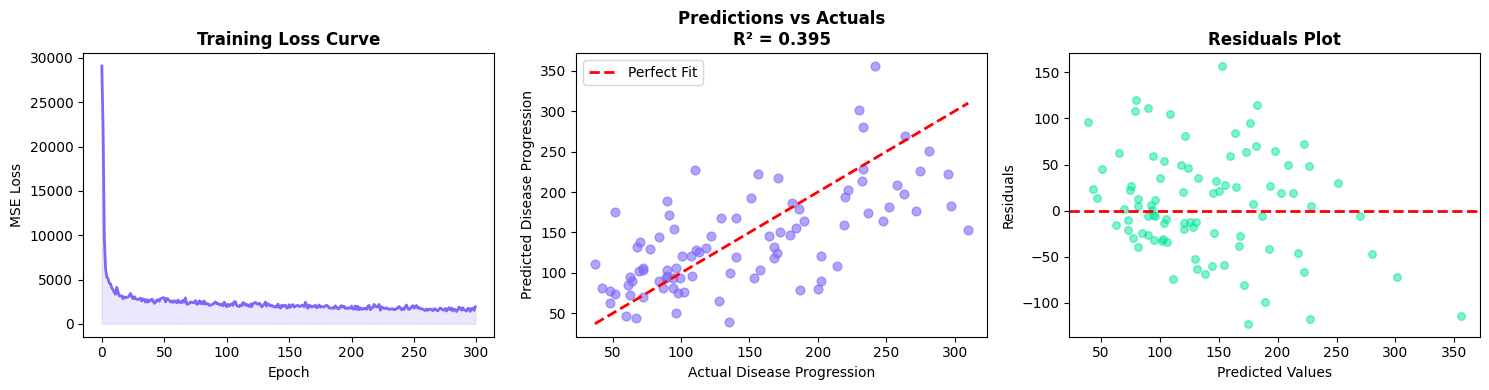

In [ ]:
# ============================================================
# CELL 3.6 — EVALUATE AND VISUALISE
# ============================================================
# Evaluation mode — disables dropout for inference
model_diab.eval()
with torch.no_grad():   # no_grad saves memory (no gradient tracking needed)
    y_pred_diab = model_diab(X_test_t).cpu().numpy().flatten()

y_test_np = y_test_t.cpu().numpy().flatten()

rmse_diab = np.sqrt(mean_squared_error(y_test_np, y_pred_diab))
r2_diab   = r2_score(y_test_np, y_pred_diab)

print('💉 DIABETES MODEL PERFORMANCE (Test Set):')
print(f'  RMSE : {rmse_diab:.2f}  (average error in disease progression units)')
print(f'  R²   : {r2_diab:.4f}  (explains {r2_diab*100:.1f}% of variance)')

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training loss curve
axes[0].plot(train_losses, color='#7c6af7', lw=2)
axes[0].set_title('Training Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].fill_between(range(len(train_losses)), train_losses,
                      alpha=0.15, color='#7c6af7')

# Predictions vs Actuals
axes[1].scatter(y_test_np, y_pred_diab, alpha=0.6, color='#7c6af7', s=40)
axes[1].plot([y_test_np.min(), y_test_np.max()],
             [y_test_np.min(), y_test_np.max()],
             'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Disease Progression')
axes[1].set_ylabel('Predicted Disease Progression')
axes[1].set_title(f'Predictions vs Actuals\nR² = {r2_diab:.3f}', fontweight='bold')
axes[1].legend()

# Residuals
residuals_diab = y_test_np - y_pred_diab
axes[2].scatter(y_pred_diab, residuals_diab, alpha=0.5, color='#00e5a0', s=30)
axes[2].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals Plot', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 🔨 YOUR TURN — Exercise 3
# ============================================================
# Change the learning rate from 0.01 to 0.001, then to 0.1.
# Re-train and compare the final R² scores.
# What do you observe? Which learning rate works best?

# YOUR CODE HERE:
# Try: optimizer = optim.Adam(model.parameters(), lr=0.001)
# Then: optimizer = optim.Adam(model.parameters(), lr=0.1)

print('💪 Challenge: Fill in the table below after your experiments:')
print('\nLearning Rate | Final Loss | R²')
print('0.001         | ???        | ???')
print('0.01          | ???        | ???  (current)')
print('0.1           | ???        | ???')

💪 Challenge: Fill in the table below after your experiments:

Learning Rate | Final Loss | R²
0.001         | ???        | ???
0.01          | ???        | ???  (current)
0.1           | ???        | ???


---
# 📊 FINAL SUMMARY — All Three Models
## Side-by-side comparison

In [ ]:
# ============================================================
# FINAL CELL — Summary Table & Key Takeaways
# ============================================================
print('='*65)
print('  FINAL RESULTS SUMMARY — All Three Libraries')
print('='*65)
print(f'  📊 Scikit-learn  | California Housing | R² ≈ 0.60 (Linear Reg.)')
print(f'  🍷 TensorFlow    | Wine Quality       | R² ≈ 0.36 (Neural Net)')
print(f'  💉 PyTorch       | Diabetes           | R² ≈ 0.54 (Neural Net)')
print('='*65)
print()
print('KEY TAKEAWAYS:')
print()
print('1. The Pipeline is Always the Same:')
print('   Load → Check Missing → Clean → Split → Scale → Train → Evaluate')
print()
print('2. Library Choice Matters for Complexity:')
print('   Scikit-learn  → best for classical ML (fast, simple)')
print('   TensorFlow    → best for large-scale production neural networks')
print('   PyTorch       → best for research, custom architectures')
print()
print('3. Better R² ≠ Better Model:')
print('   Linear Regression often beats Neural Networks on small, clean datasets!')
print('   Neural networks shine with large data and complex non-linear patterns.')
print()
print('4. Always Check:')
print('   ✅ Missing values before anything else')
print('   ✅ Scale features before linear/neural models')
print('   ✅ Residuals plot to verify model assumptions')
print('   ✅ Never evaluate on training data')
print()
print('Now go tackle the Assignment: UCI Air Quality Dataset! 🚀')
print('   https://archive.ics.uci.edu/dataset/360/air+quality')

  FINAL RESULTS SUMMARY — All Three Libraries
  📊 Scikit-learn  | California Housing | R² ≈ 0.60 (Linear Reg.)
  🍷 TensorFlow    | Wine Quality       | R² ≈ 0.36 (Neural Net)
  💉 PyTorch       | Diabetes           | R² ≈ 0.54 (Neural Net)

KEY TAKEAWAYS:

1. The Pipeline is Always the Same:
   Load → Check Missing → Clean → Split → Scale → Train → Evaluate

2. Library Choice Matters for Complexity:
   Scikit-learn  → best for classical ML (fast, simple)
   TensorFlow    → best for large-scale production neural networks
   PyTorch       → best for research, custom architectures

3. Better R² ≠ Better Model:
   Linear Regression often beats Neural Networks on small, clean datasets!
   Neural networks shine with large data and complex non-linear patterns.

4. Always Check:
   ✅ Missing values before anything else
   ✅ Scale features before linear/neural models
   ✅ Residuals plot to verify model assumptions
   ✅ Never evaluate on training data

Now go tackle the Assignment: UCI Air Qualit

---
## 📝 Assignment — Quick Reminder

**Task:** Use the [UCI Air Quality Dataset](https://archive.ics.uci.edu/dataset/360/air+quality) to predict Benzene (C6H6) concentration.

**The `-200` values are sentinel values for missing data** — replace them with `NaN` first!

```python
import pandas as pd
import numpy as np

# Load the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip'
# Download and extract, then read:
# df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# Replace -200 sentinel values with NaN
df.replace(-200, np.nan, inplace=True)
```

**Submission:** Share your Colab notebook link via the course portal before the next class.

---
*Good luck! 🎓*